# **Optimizing Solar Tracking using AI**

This project trains a feedforward Artificial Neural Network (ANN) to predict hourly distributed solar energy output (MWh) for Gilmer County, Georgia. Solar altitude and azimuth are used as input features, computed from real county-level generation data provided by the Lawrence Berkeley National Laboratory.

The goal is to establish a baseline predictive model that could inform real-time solar panel orientation and energy forecasting systems.

**Implemented:**
- Artificial Neural Network (ANN)

**Planned:**
- Kolmogorov-Arnold Networks (KAN)
- Recurrent Neural Networks (RNN)
- Radial Basis Function (RBF)
- Modular Neural Network (Mod-NN)


In [33]:
# Data science & analytics libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Solar position calculation library
from pysolar.solar import *
import datetime
from datetime import timezone

import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Solar Tracking Data

The dataset is a subset of the 8.7GB Solar-to-Grid Public Data File produced by Lawrence Berkeley National Laboratory, covering hourly county-level distributed PV generation across U.S. wholesale markets from 2012–2020.

The specific file used is `13123.csv`, where `13123` is the FIPS code for **Gilmer County, Georgia** (State FIPS: 13, County FIPS: 123). Data is filtered to the peak solar season: **May–September 2019**.

**Source:** [Lawrence Berkeley National Lab. (2021). Solar-to-Grid Public Data File](https://doi.org/10.25984/1825661)

In [34]:
# Converts a timestamp string or numeric value to a timezone-aware datetime object.
# Handles three formats: Unix timestamps (int/float), numeric strings, and ISO 8601 strings.
# Timezone awareness is required by pysolar for accurate solar position calculations.
def convertStrToDateTime(date_time:str)->datetime.datetime:
    if isinstance(date_time, (int, float)):
        return datetime.datetime.fromtimestamp(date_time, tz=datetime.timezone.utc)
    elif isinstance(date_time, str) and date_time.replace('.', '', 1).isdigit():
        return datetime.datetime.fromtimestamp(float(date_time), tz=datetime.timezone.utc)
    
    try:
        return datetime.datetime.strptime(date_time, '%Y-%m-%d %H:%M:%S%z')
    except ValueError:
        return datetime.datetime.strptime(date_time, '%Y-%m-%d %H:%M:%S')

### Data Processing

The data processing necessary for us to operate within our own parameters is important since we are mostly focused on a specific year & season [May, September] 2019.

#### Required functions for ease of data processing

In [35]:
# Returns a slice of the dataframe between two timestamp strings (inclusive start).
# Used to isolate the May–September 2019 window from the full 2012–2020 dataset.
def trimDataByTimeFrame(data:pd.DataFrame, start_date_and_time:str, end_date_and_time:str):
  return data[data.index[data['Date_and_Time'] == start_date_and_time].tolist()[0]:
              data.index[data['Date_and_Time'] == end_date_and_time].tolist()[0]]

# General purpose plotting function for visualizing relationships between two variables.
def plotData(x, y, x_label:str, y_label:str, title:str):
  plt.plot(x, y)
  plt.xlabel(x_label)
  plt.ylabel(y_label)
  plt.title(title)
  plt.show()

#### Solar Data - Data Pruning & Analysis
Data Is from Gilmer Counter Georgia


In [36]:
# Read csv file & properly assign the dataframe with column names
df = pd.read_csv("13123.csv")
df.columns = ['Date_and_Time', 'DPV_res_MW', 'DPV_non_res_MW', 'CF', 'DPV_res_MWh', 'DPV_non_res_MWh']

# desired time frame
sdat = "2019-01-01 00:00:00+00:00"
edat = "2019-12-01 00:00:00+00:00"

# trim the data
timed_data = trimDataByTimeFrame(df, start_date_and_time=sdat, end_date_and_time=edat)
timed_data.to_csv("trimed_data.csv", index=False)

# prune the data so that we don't have to deal with this later
pruned_data = timed_data.copy()

# combine like terms
pruned_data.loc[:,"DPV_Combined_MW"] = pruned_data['DPV_res_MW'] + pruned_data['DPV_non_res_MW']
pruned_data.loc[:,"DPV_Combined_MWh"] = pruned_data['DPV_res_MWh'] + pruned_data['DPV_non_res_MWh']

# drop data
for i in ['DPV_res_MW', 'DPV_non_res_MW', 'CF', 'DPV_res_MWh', 'DPV_non_res_MWh']:
  pruned_data.pop(i)

# save data to csv and print out the finally pruned data
pruned_data.to_csv("pruned_data.csv", index=False)
print("Pruned Data")
print(pruned_data.head())

# For the solar angle relative to position calculations
pruned_data["Date_and_Time"].to_csv("date_times.csv", index=False)
input_data = pruned_data.copy()

Pruned Data
                   Date_and_Time  DPV_Combined_MW  DPV_Combined_MWh
78883  2019-01-01 00:00:00+00:00         0.048244               0.0
78884  2019-01-01 01:00:00+00:00         0.048246               0.0
78885  2019-01-01 02:00:00+00:00         0.048248               0.0
78886  2019-01-01 03:00:00+00:00         0.048250               0.0
78887  2019-01-01 04:00:00+00:00         0.048252               0.0


#### Output Data - Data Pruning & Analysis

In [37]:
latitude = 34.766402181439396
longitude = -84.5666744211403

def calculate_solar_angles(timestamps, lat,long):
    altitudes = []
    azimuths = []

    for t in timestamps:
        dt = convertStrToDateTime(t).replace(tzinfo=timezone.utc)
        altitudes.append(get_altitude(lat, long, dt))
        azimuths.append(get_azimuth(lat, long, dt))

    return altitudes, azimuths    

altitudes, azimuths = calculate_solar_angles(pruned_data["Date_and_Time"], latitude, longitude)
pruned_data["Solar_Altitude"] = altitudes
pruned_data["Solar_Azimuth"] = azimuths

#convert azimuth to rad
azimuth_rad = np.deg2rad(pruned_data['Solar_Azimuth'])

# Create new columns for sin and cos of azimuth
pruned_data['azimuth_sin'] = np.sin(azimuth_rad)
pruned_data['azimuth_cos'] = np.cos(azimuth_rad)

pruned_data[["Date_and_Time", "Solar_Altitude", "Solar_Azimuth", "azimuth_sin", "azimuth_cos"]].to_csv("solar_angles_with_sincos_2019.csv", index=False)

#Print head to preview data
print(pruned_data[['Solar_Altitude', 'azimuth_sin', 'azimuth_cos']].head())

       Solar_Altitude  azimuth_sin  azimuth_cos
78883      -16.524933    -0.956721    -0.291007
78884      -28.507217    -0.986281    -0.165078
78885      -40.753620    -0.999533    -0.030556
78886      -53.043307    -0.991448     0.130506
78887      -64.978929    -0.932420     0.361377


## Artificial Neural Network (ANN)

The purpose of the ANN is to show the capabilities of a functional AI based on the traditional methods of using AI to solve problems. The solar tracking is done by passing [Solar Altitude, Azimuth (sin), and Azimuth (cos)] to the input and the output is [MWh].


### ANN Class

In [38]:
#ANN Class
class SolarTrackingNN(nn.Module):
  def __init__(self):
    super(SolarTrackingNN, self).__init__()
    self.fc1 = nn.Linear(3,32) # First hidden layer: 3 inputs → 32 neurons
    self.fc2 = nn.Linear(32,32) # Second hidden layer: 32 → 32 neurons
    self.fc3 = nn.Linear(32,1 ) # Output layer: 32 → 3 outputs

    #Foward pass
  def forward(self, x):
    x = torch.relu(self.fc1(x)) # ReLU activation
    x = torch.relu(self.fc2(x)) # ReLU activation
    x = self.fc3(x)             # Linear output
    return x

#Created model
AI_model = SolarTrackingNN()
#Loss function
loss_funct = nn.MSELoss()
#Optimizer
Optimizer = optim.Adam(AI_model.parameters(), lr=0.0001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(Optimizer, patience=10, factor=0.5)
#Data Preparation
pruned_data = pruned_data[pruned_data['Solar_Altitude'] > 0].copy()

#Input Features X
X_df = pruned_data[['Solar_Altitude', 'azimuth_sin', 'azimuth_cos']].copy()

#Targets Variable Y
y_df = pruned_data[['DPV_Combined_MWh']].copy()

print(X_df.head())
print(y_df.head())

print(pruned_data['DPV_Combined_MWh'].describe())

# Splitting into training, validation, and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_df, y_df, test_size=0.15, random_state=42 # 15% for test set
)

# Then split training+validation into training and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1765, random_state=42 # Approx 15% of original for val
)

#Input features and scalars
scaler = StandardScaler()

#Fitting scalar to only input features
X_train_scaled = scaler.fit_transform(X_train)
#Applying the same scalar to validation and test features
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)



#Converting all scalers to pytorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)


#Creating respective datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

#Set standard batch size
batch_size=64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False) # Set val and test to false for consistent performance
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

#Printing for testing purposes
print(f"Training samples: {len(X_train_tensor)}")
print(f"Validation samples: {len(X_val_tensor)}")
print(f"Test samples: {len(X_test_tensor)}")



       Solar_Altitude  azimuth_sin  azimuth_cos
78896        2.050032     0.867707    -0.497077
78897       11.986496     0.774646    -0.632396
78898       20.710237     0.638064    -0.769983
78899       27.436584     0.445349    -0.895357
78900       31.433442     0.195430    -0.980718
       DPV_Combined_MWh
78896          0.000417
78897          0.002668
78898          0.007390
78899          0.007713
78900          0.008326
count    4110.000000
mean        0.019276
std         0.014662
min         0.000000
25%         0.005106
50%         0.017391
75%         0.032808
max         0.048955
Name: DPV_Combined_MWh, dtype: float64
Training samples: 2876
Validation samples: 617
Test samples: 617


### ANN Training

Epoch 1 Training completed. Average training Loss: 0.010274
Epoch 1 Validation Completed. Average Val Loss: 0.005929
 Average Val MAE: 0.0622
Epoch 2 Training completed. Average training Loss: 0.003856
Epoch 2 Validation Completed. Average Val Loss: 0.002226
 Average Val MAE: 0.0385
Epoch 3 Training completed. Average training Loss: 0.001486
Epoch 3 Validation Completed. Average Val Loss: 0.000846
 Average Val MAE: 0.0242
Epoch 4 Training completed. Average training Loss: 0.000641
Epoch 4 Validation Completed. Average Val Loss: 0.000416
 Average Val MAE: 0.0161
Epoch 5 Training completed. Average training Loss: 0.000384
Epoch 5 Validation Completed. Average Val Loss: 0.000296
 Average Val MAE: 0.0132
Epoch 6 Training completed. Average training Loss: 0.000301
Epoch 6 Validation Completed. Average Val Loss: 0.000252
 Average Val MAE: 0.0121
Epoch 7 Training completed. Average training Loss: 0.000261
Epoch 7 Validation Completed. Average Val Loss: 0.000228
 Average Val MAE: 0.0115
Epoch 

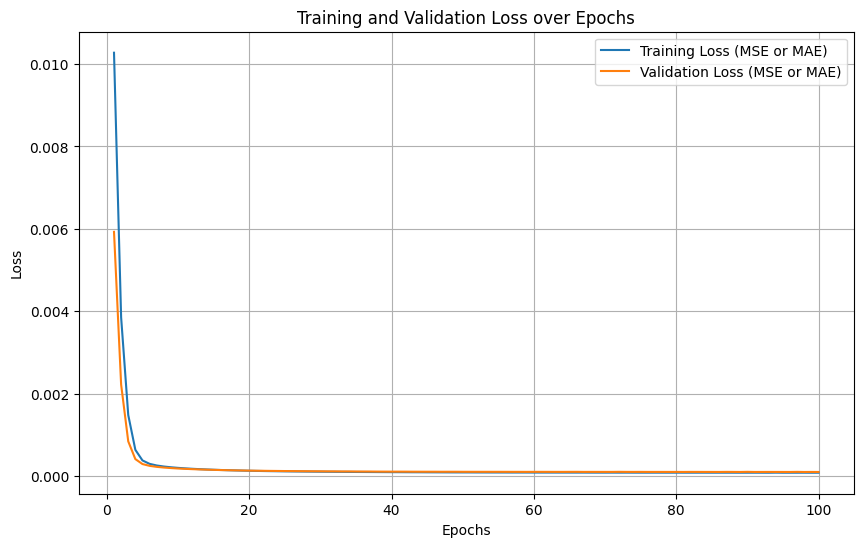

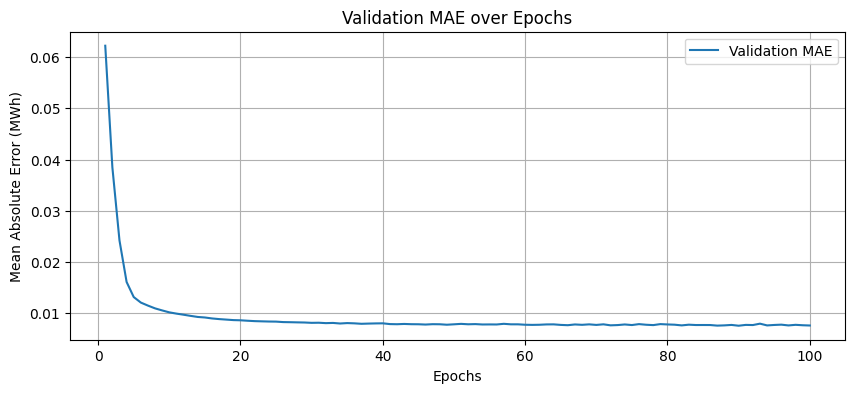

In [39]:
def train(model, train_loader, val_loader, loss_function, optimizer, scheduler, epochs=10):
    model.train()  # Set model to training mode
    training_loss_history = []
    val_loss_history = []
    val_mae_history = []
    
    for epoch in range(epochs):


        #Training Phase
        model.train()
        running_train_loss = 0.0
        batch_training_losses = []
        
        for batch_idx, (inputs, targets) in enumerate(train_loader):
            # Zero the gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(inputs)
            loss = loss_function(outputs, targets)
            
            # Backward pass and optimize
            loss.backward()
            optimizer.step()
            
            # Track loss
            running_train_loss += loss.item() * inputs.size(0)
            batch_training_losses.append(loss.item())
            
            # Print batch statistics
            if batch_idx % 100 == 99:  # Print every 100 batches
                avg_batch_loss = sum(batch_training_losses[-100:])/100
                print(f'Epoch {epoch+1}, Batch {batch_idx+1}, Loss: {avg_batch_loss:.6f}')
        
        # Calculate average epoch loss
        epoch_training_loss = running_train_loss / len(train_loader.dataset)
        training_loss_history.append(epoch_training_loss)
        print(f'Epoch {epoch+1} Training completed. Average training Loss: {epoch_training_loss:.6f}')



        #Validation Phase
        model.eval()
        running_val_loss = 0.0
        running_val_mae = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                outputs = model(inputs)
                loss = loss_function(outputs, targets)
                running_val_loss += loss.item() * inputs.size(0)

                mae = torch.nn.functional.l1_loss(outputs, targets, reduction='sum')
                running_val_mae += mae.item()        

        epoch_val_mae = running_val_mae / (len(val_loader.dataset)) 
        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        val_loss_history.append(epoch_val_loss)
        val_mae_history.append(epoch_val_mae)
        print(f'Epoch {epoch+1} Validation Completed. Average Val Loss: {epoch_val_loss:.6f}')
        print(f' Average Val MAE: {epoch_val_mae:.4f}')

        scheduler.step(epoch_val_loss)

    model.eval()
    print("\n--- Sample Predictions from Validation Set (End of Training) ---")
    with torch.no_grad():
        for i, (inputs, targets) in enumerate(val_loader):
            if i >= 1: # Look at first 5 batches for example
                break
            outputs = model(inputs)
            for j in range(min(inputs.size(0), 5)):
                pred_MWh = outputs[j][0].item()
                actual_MWh = targets[j][0].item()
                error = pred_MWh - actual_MWh
                print(f"Sample {j+1}:")
                print(f"  Predicted MWh: {pred_MWh:.6f}")
                print(f"  Actual MWh:    {actual_MWh:.6f}")
                print(f"  Error:         {error:.6f}")
                print("-" * 20)
               
    return training_loss_history, val_loss_history, val_mae_history

# Train the model
train_loss_hist, val_loss_hist , val_mae_history = train(AI_model, train_loader, val_loader, loss_funct, Optimizer, scheduler, epochs=100)

# Plotting loss over epochs
def plot_loss_curves(train_loss_history, val_loss_history): # Takes actual loss history lists
  num_epochs = len(train_loss_history)
  plt.figure(figsize=(10, 6))
  plt.plot(range(1, num_epochs + 1), train_loss_history, label='Training Loss (MSE or MAE)')
  plt.plot(range(1, num_epochs + 1), val_loss_history, label='Validation Loss (MSE or MAE)')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.title('Training and Validation Loss over Epochs')
  plt.legend()
  plt.grid(True)
  # To save the figure:
  # plt.savefig('loss_curves.png')
  plt.show()

plot_loss_curves(train_loss_hist, val_loss_hist)

plt.figure(figsize=(10, 4))
plt.plot(range(1, 100 + 1), val_mae_history, label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error (MWh)')
plt.title('Validation MAE over Epochs')
plt.legend()
plt.grid(True)
plt.show()

### ANN Test

In [40]:
#Define the test function for ANN
def test_model(model, loss_funct, test_loader):
  #Switch Model out of training mode to testing mode
  model.eval()

  #Totals for each value, to be divided at the end
  running_loss = 0.0
  running_mae = 0.0
  running_rmse = 0.0
  total = 0

  #Disabling gradients since no weight updates are needed
  with torch.no_grad():
    #running test inputs
    for inputs, targets in test_loader:
      outputs = model(inputs)
      loss = loss_funct(outputs, targets)
      running_loss += loss.item() * inputs.size(0)

      #Average absolute difference between predicted and actual values
      mae = torch.nn.functional.l1_loss(outputs, targets, reduction='sum')
      running_mae += mae.item()

      #Square the errors, sum them, and track how many samples we've seen
      rmse = ((outputs - targets) ** 2).sum().item()
      running_rmse += rmse
      total += targets.size(0)

  #Calculations for loss and accuracy
  average_loss = running_loss / total
  average_mae = running_mae / total
  average_rmse = (running_rmse / total) ** 0.5


  #Results of the test loader
  print(f'Test Loss: {average_loss:.6f}')
  print(f'Test MAE: {average_mae:.6f}')
  print(f'Test RMSE: {average_rmse:.6f}')

  return average_loss, average_mae, average_rmse

#Test model
average_loss, average_mae, average_rmse = test_model(AI_model, loss_funct, test_loader)

Test Loss: 0.000087
Test MAE: 0.006968
Test RMSE: 0.009339


In [41]:
torch.save(AI_model.state_dict(), 'ann_solar_model.pth')